# Partitions And Path Covers

This notebook looks at operators that turn one mapped subgraph into coarser pieces: ranked centrality chunks, overlapping hop windows, low-cut parts, and bounded shortest-path covers.

Previous: [02 Composition And Add](./example_abstract_graph_operators_02_composition_and_add.ipynb)  
Next: [04 Merge And Complements](./example_abstract_graph_operators_04_merge_and_complements.ipynb)


## What you will see

Partition-style operators are useful when the subgraph is too large for motif enumeration but you still want structured pieces. The examples below compare four strategies on the same graph:

1. `betweenness_centrality_split(...)` ranks nodes and chunks them by centrality.
2. `betweenness_centrality_hop_split(...)` grows overlapping hop windows from central nodes.
3. `low_cut_partition(...)` recursively splits oversized regions while keeping small interfaces.
4. `shortest_path_cover(...)` emits bounded paths whose union covers every edge.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')


In [3]:
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings
from abstractgraph.operators import *


def draw(graph, decomposition_function, *, nbits=11, size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(graph, decomposition_function=decomposition_function, nbits=nbits)
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


## A graph with bridges and dense pockets

The graph has a dense left cluster, a dense right cluster, and a narrow middle corridor. That shape makes the contrast between centrality chunks, hop windows, low-cut partitions, and edge-covering paths easier to see.


Graph with 14 nodes and 16 edges


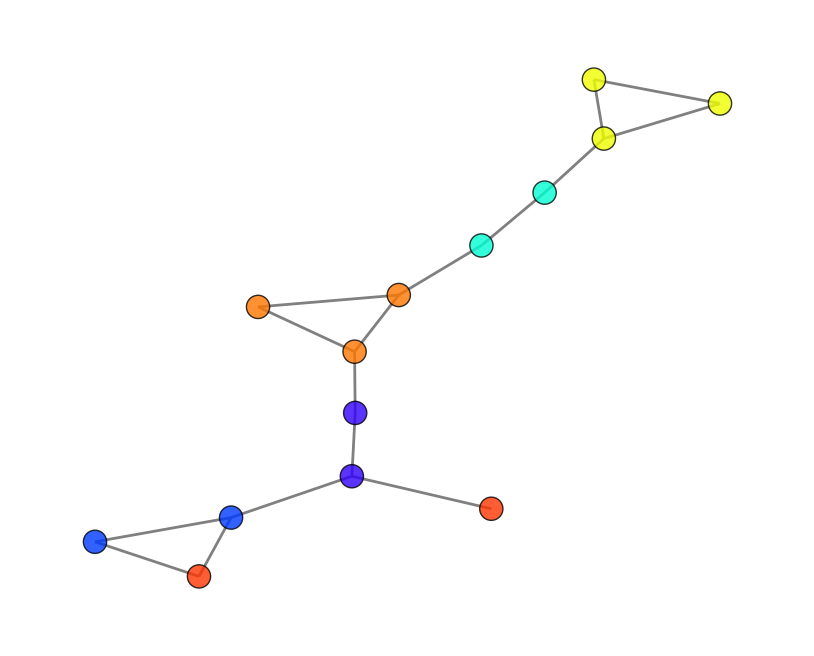

In [4]:
graph = nx.Graph()
graph.add_nodes_from([
    (0, {'label': 'A'}),
    (1, {'label': 'A'}),
    (2, {'label': 'A'}),
    (3, {'label': 'B'}),
    (4, {'label': 'B'}),
    (5, {'label': 'C'}),
    (6, {'label': 'C'}),
    (7, {'label': 'C'}),
    (8, {'label': 'D'}),
    (9, {'label': 'D'}),
    (10, {'label': 'E'}),
    (11, {'label': 'E'}),
    (12, {'label': 'F'}),
    (13, {'label': 'F'}),
])
graph.add_edges_from([
    (0, 1), (1, 2), (2, 0),
    (2, 3), (3, 4), (4, 5),
    (5, 6), (6, 7), (7, 5),
    (6, 8), (8, 9), (9, 10),
    (10, 11), (11, 12), (12, 10),
    (9, 13),
])

print(graph)
display_graph(graph)


## `betweenness_centrality_split(number_of_nodes=4)`

This ranks nodes by betweenness centrality and groups the ranked list into fixed-size chunks. It is a coarse global view: central bridge nodes tend to appear in the first chunks, while peripheral nodes appear later.


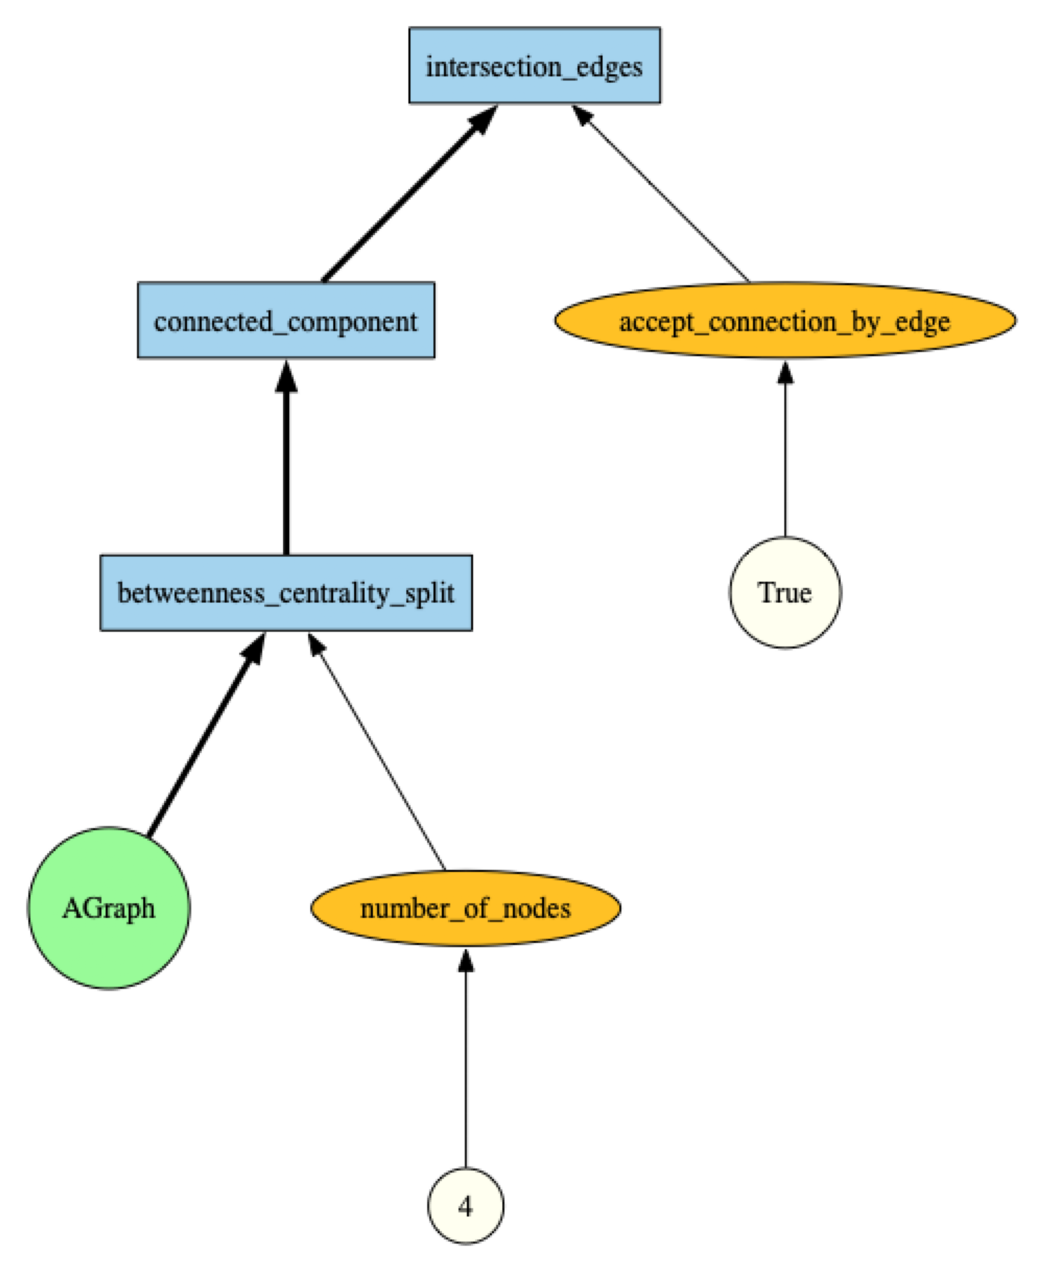

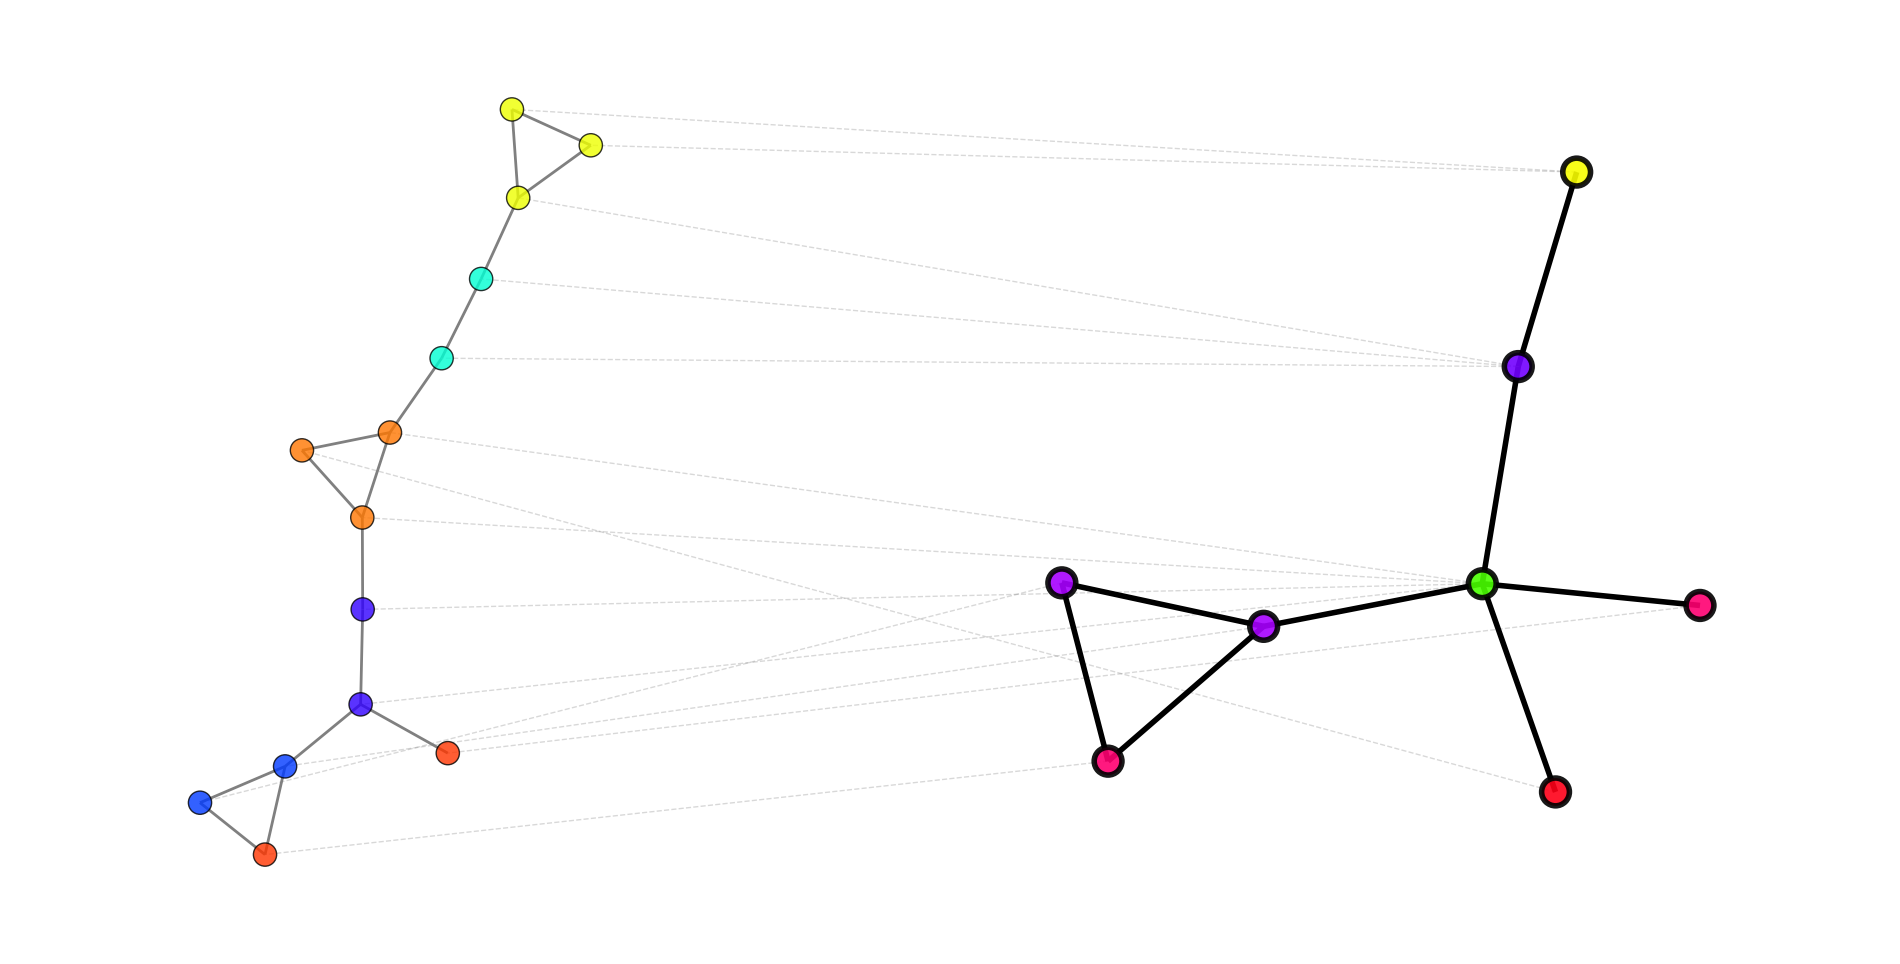

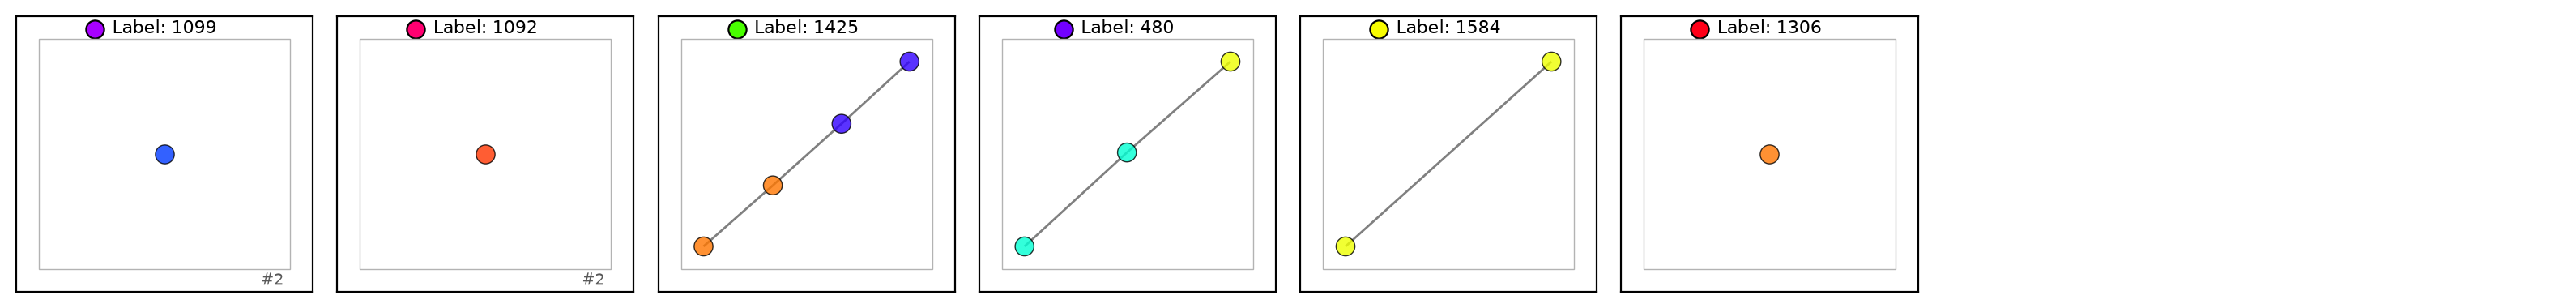

In [5]:
df = compose(
    intersection_edges(accept_connection_by_edge=True),
    connected_component(),
    betweenness_centrality_split(number_of_nodes=4),
)
betweenness_split_ag = draw(graph, df)


## `betweenness_centrality_hop_split(n_hops=2)`

Hop splitting starts from high-betweenness anchors and creates connected windows by graph distance. Adjacent windows overlap at their boundary hop, so the resulting pieces keep some shared context.


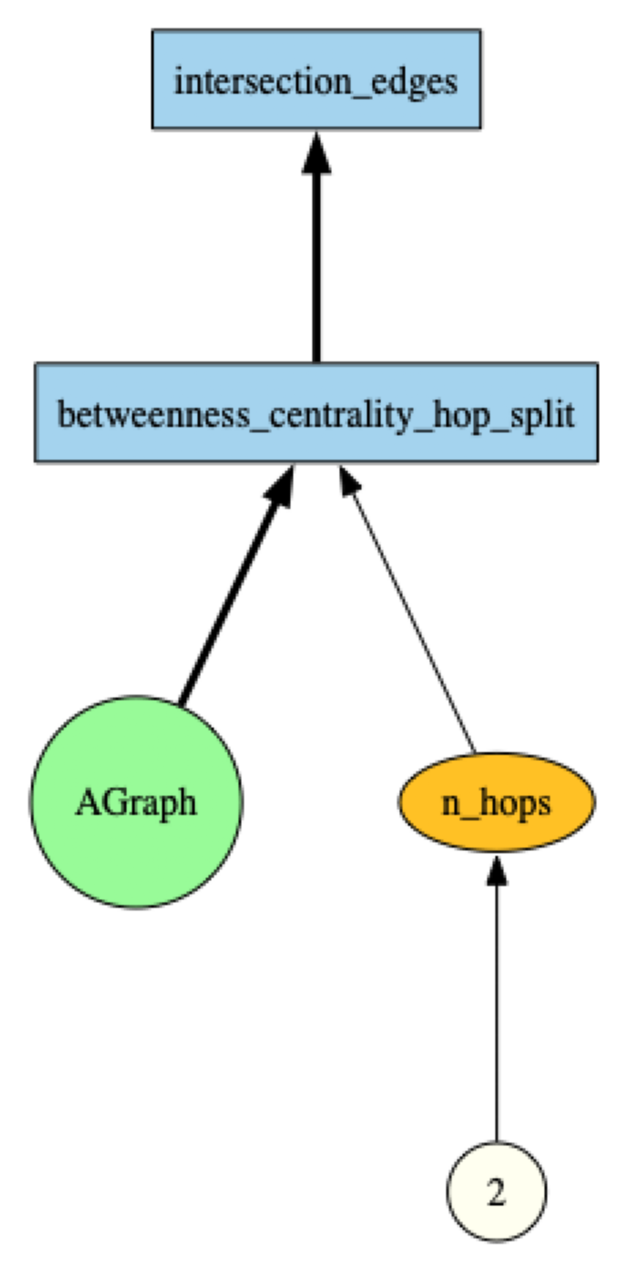

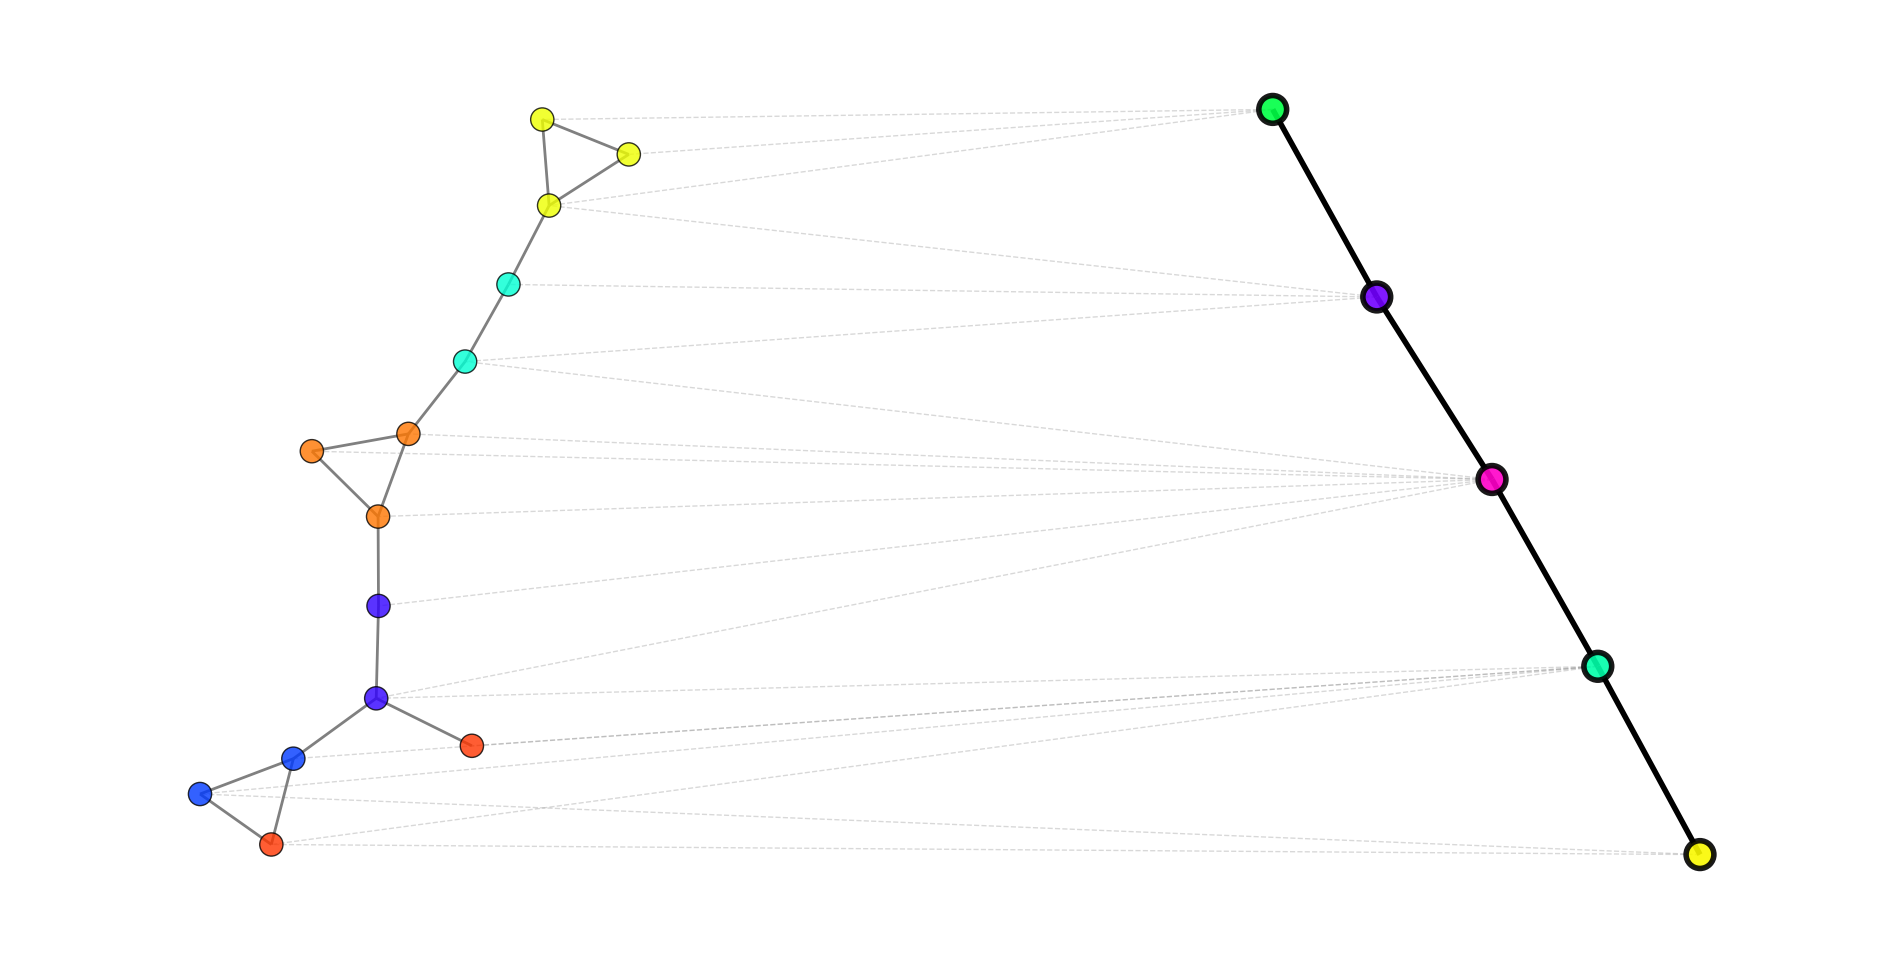

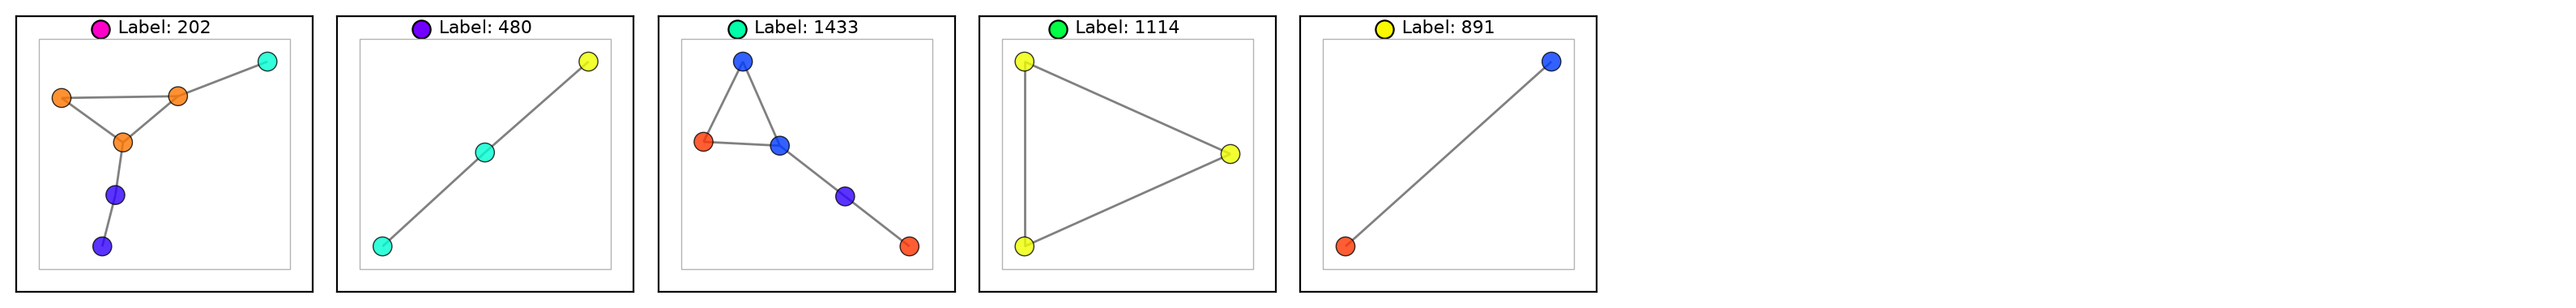

In [6]:
df = compose(
    intersection_edges(),
    betweenness_centrality_hop_split(n_hops=2),
)
hop_split_ag = draw(graph, df)


## `low_cut_partition(max_part_size=5)`

Low-cut partitioning recursively splits oversized parts while preferring small cut interfaces. The `min_overlap_nodes` setting keeps a little shared boundary context between sibling parts.


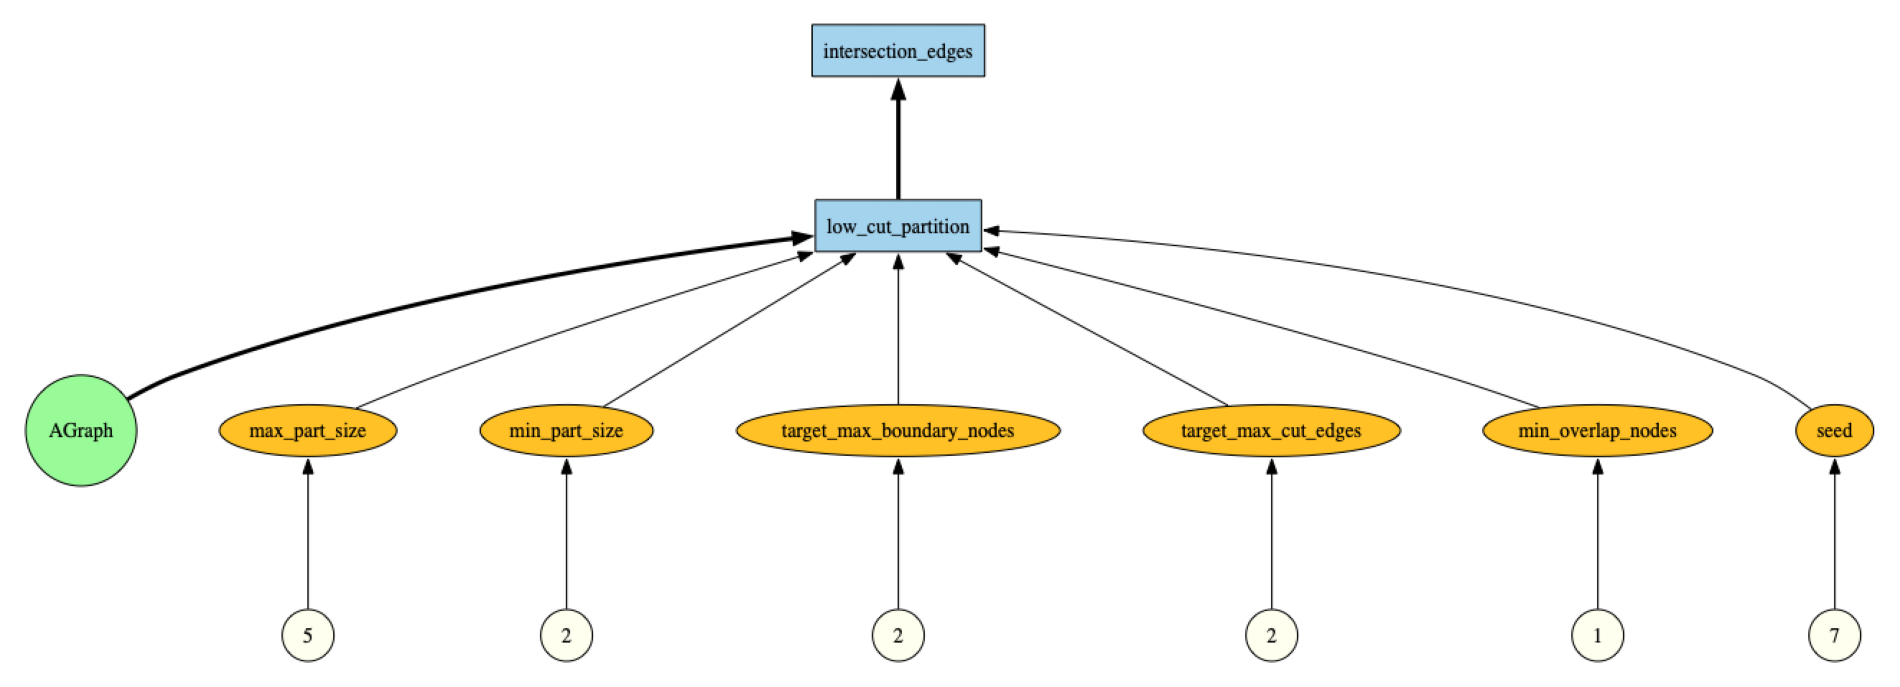

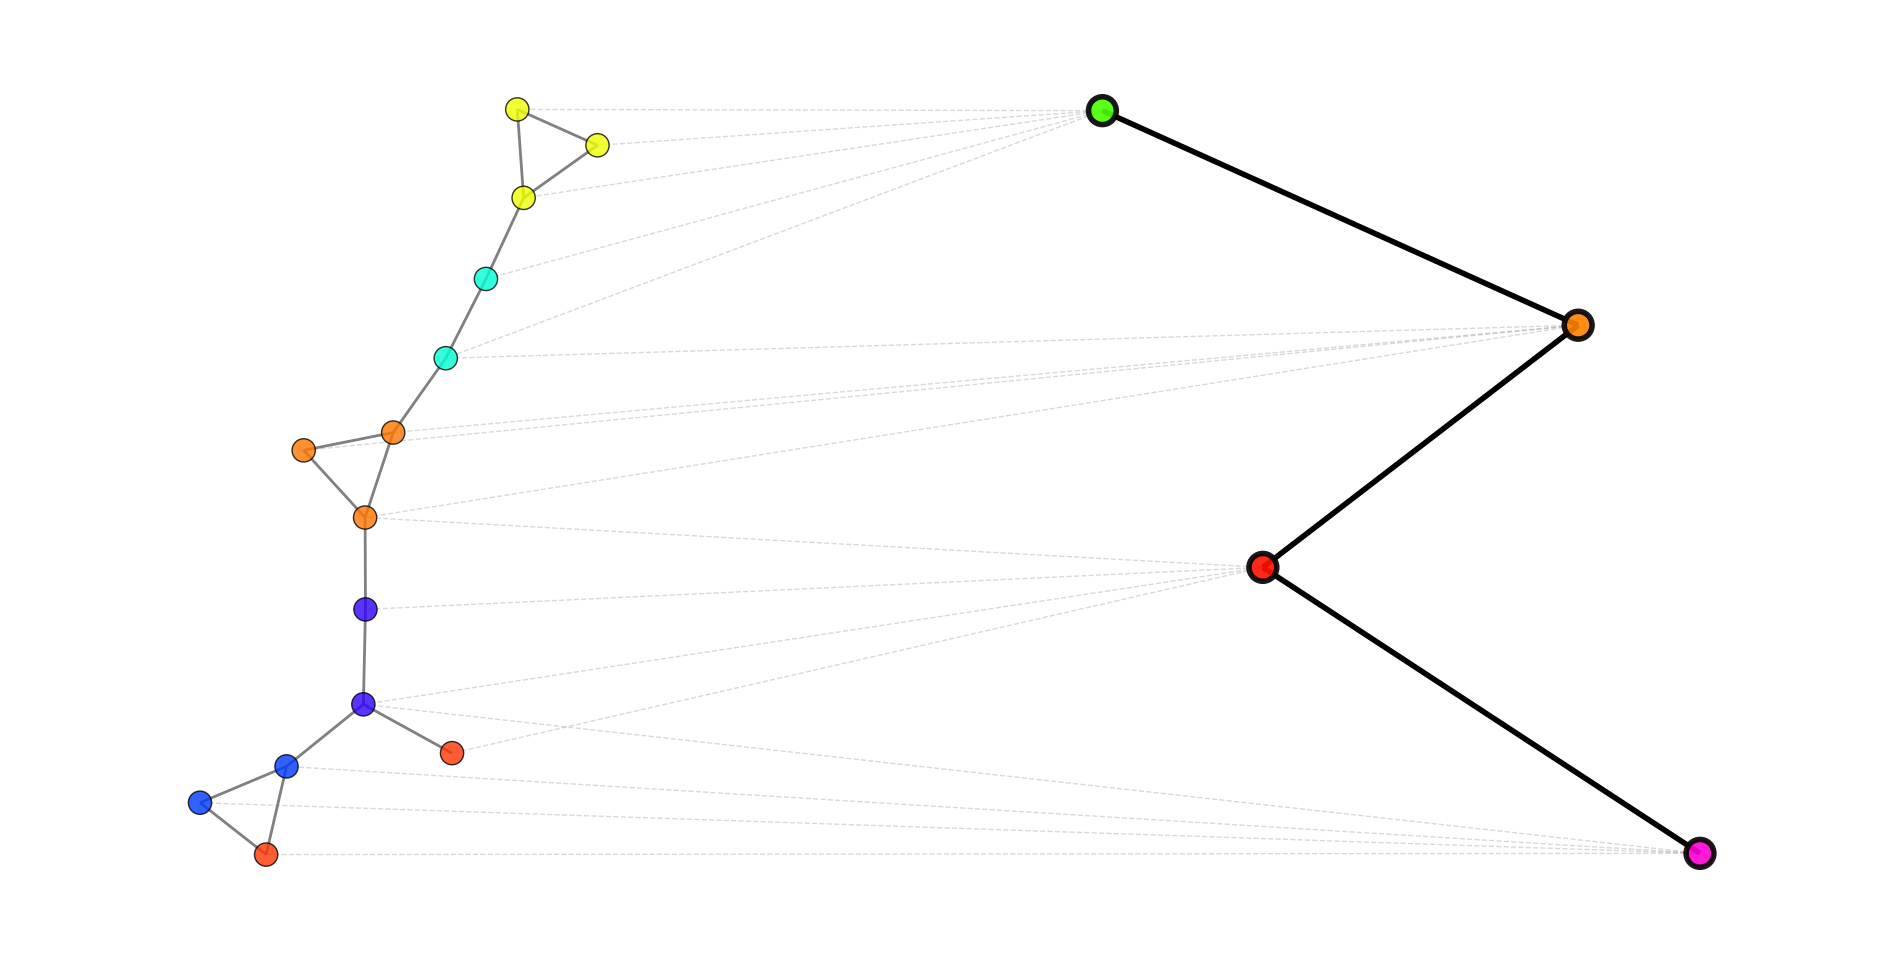

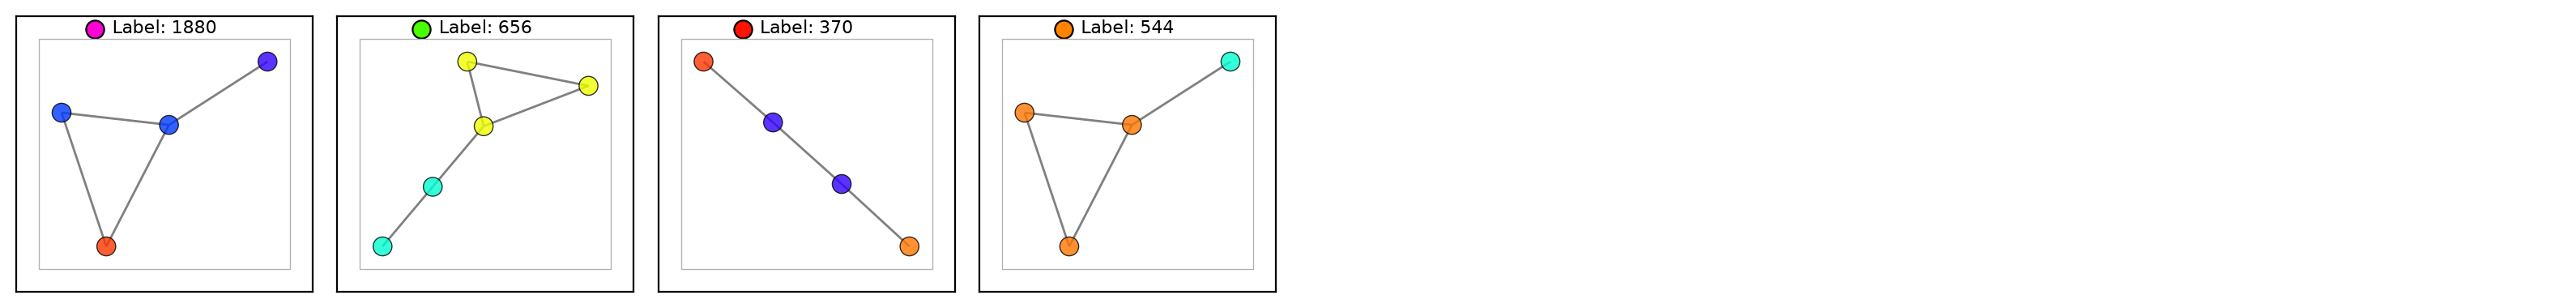

In [7]:
df = compose(
    intersection_edges(),
    low_cut_partition(
        max_part_size=5,
        min_part_size=2,
        target_max_boundary_nodes=2,
        target_max_cut_edges=2,
        min_overlap_nodes=1,
        seed=7,
    ),
)
low_cut_ag = draw(graph, df)


## `shortest_path_cover(n_edges=3)`

Shortest path cover is edge-oriented: every original edge is covered by at least one emitted path, and no emitted path has more than `n_edges` edges. This gives path-shaped pieces with overlapping nodes and complete edge coverage.


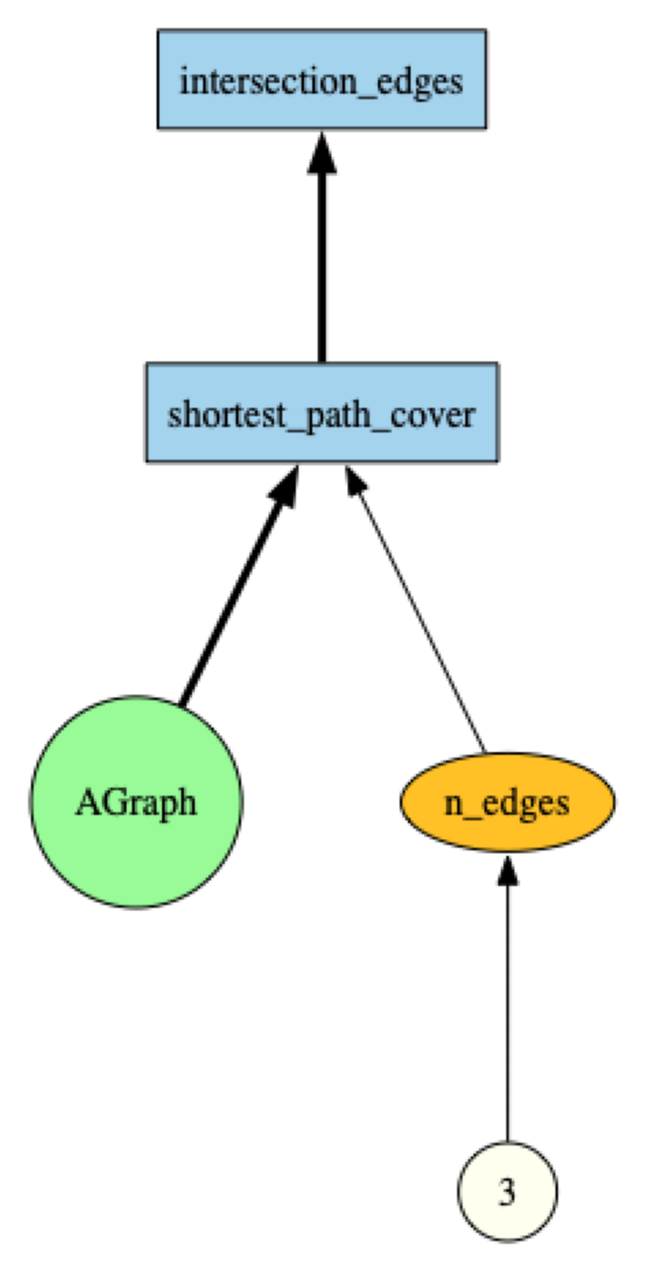

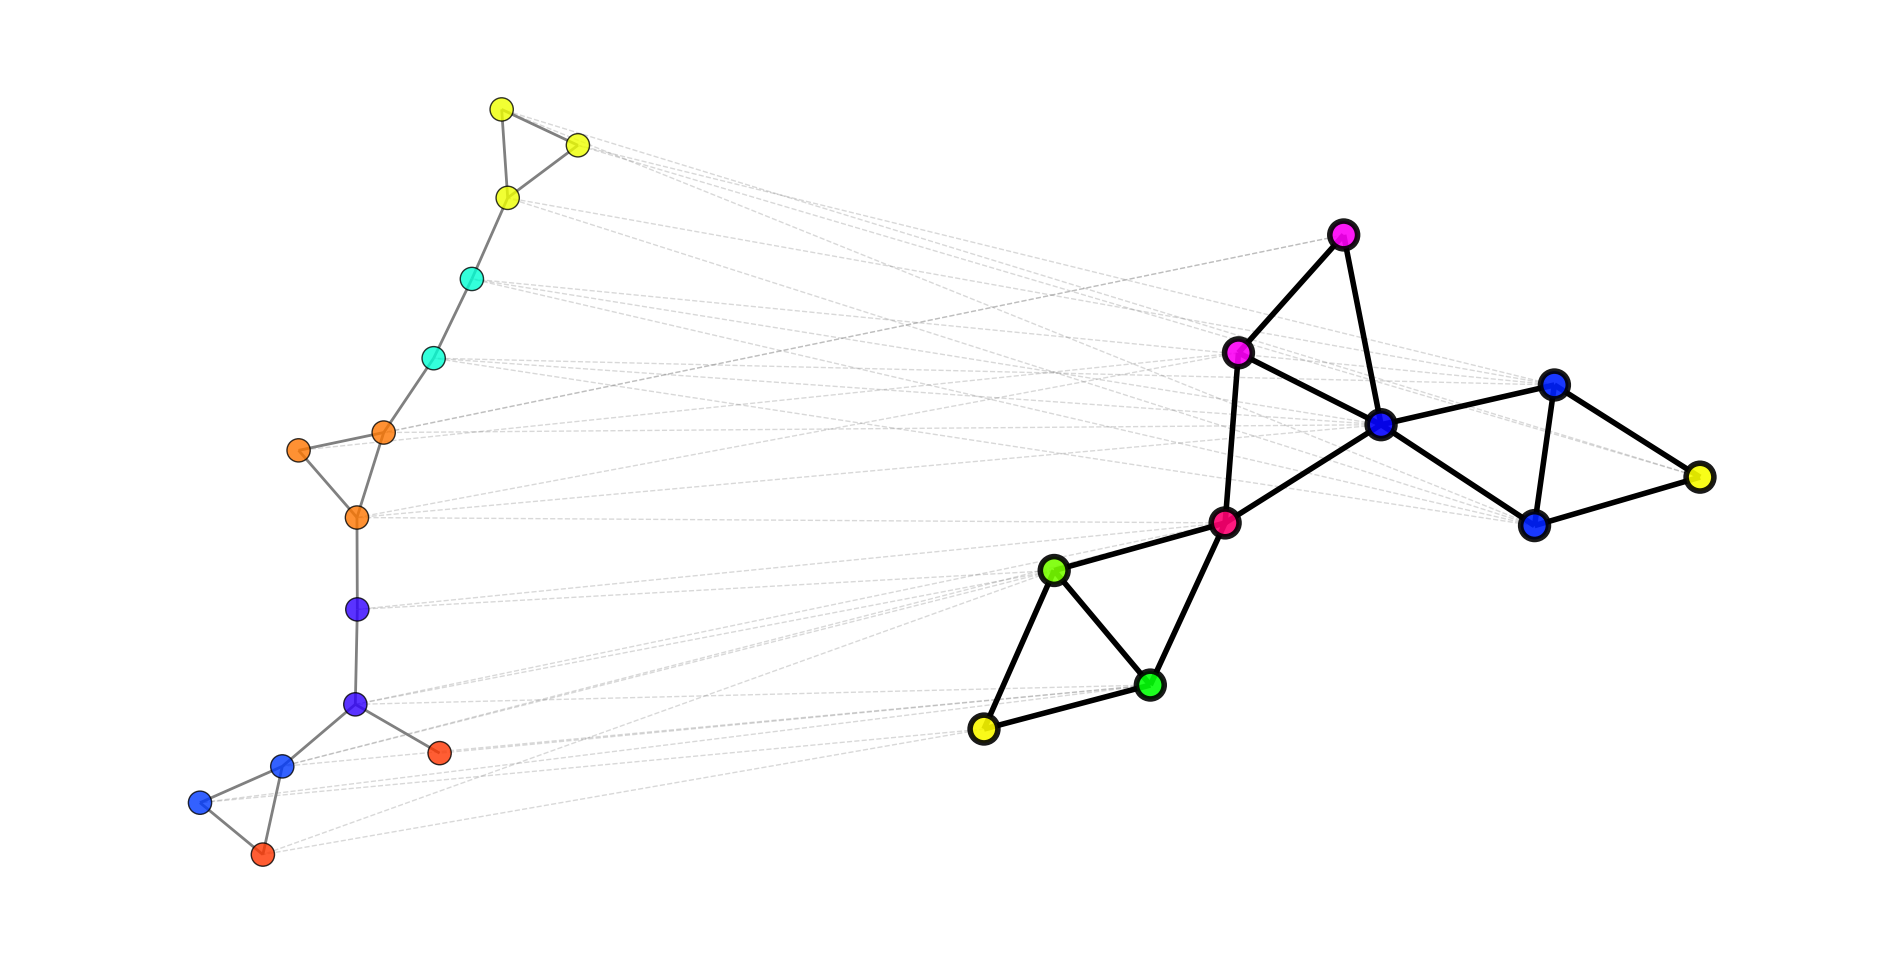

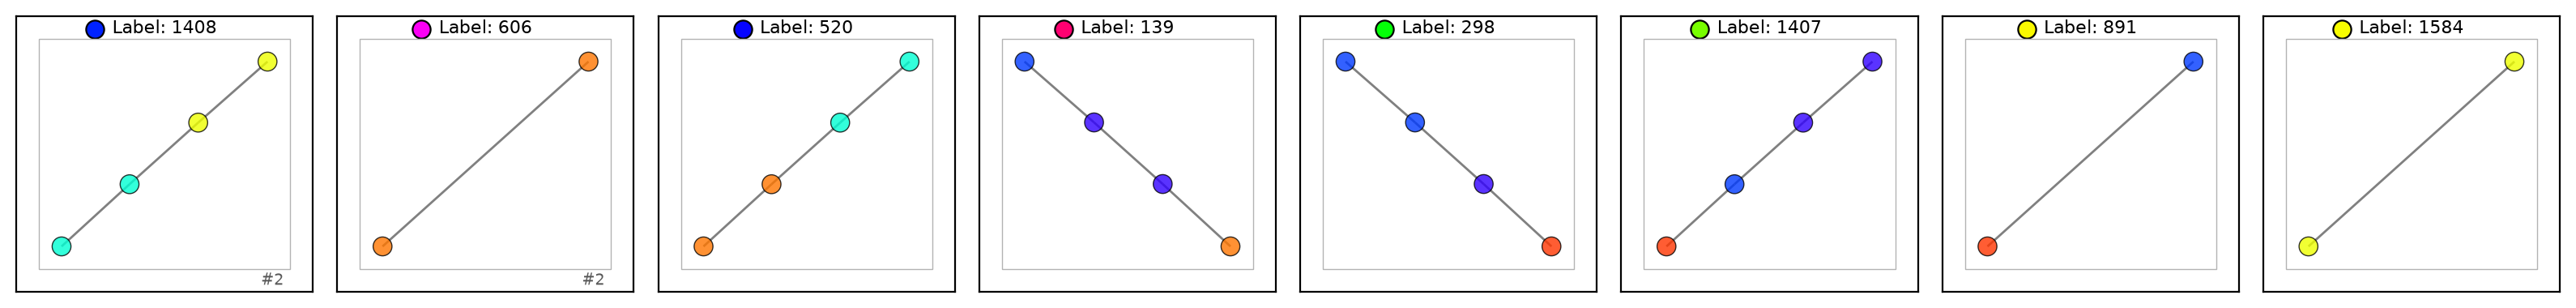

In [8]:
df = compose(
    intersection_edges(),
    shortest_path_cover(n_edges=3),
)
shortest_path_cover_ag = draw(graph, df)


## Compare the output sizes

The counts below are a compact way to compare the decompositions before looking at the drawings. For edge-covering paths, the edge counts are bounded by `n_edges`; for node partitions, the node counts show how coarse each part is.


In [9]:
def subgraph_sizes(ag):
    mapped = ag.get_interpretation_nodes_mapped_subgraphs()
    return [(subgraph.number_of_nodes(), subgraph.number_of_edges()) for subgraph in mapped]

for name, ag in [
    ('betweenness split', betweenness_split_ag),
    ('hop split', hop_split_ag),
    ('low cut', low_cut_ag),
    ('shortest path cover', shortest_path_cover_ag),
]:
    sizes = subgraph_sizes(ag)
    print(f'{name:>20}: {len(sizes)} parts -> {sizes}')


   betweenness split: 8 parts -> [(4, 3), (3, 2), (1, 0), (2, 1), (1, 0), (1, 0), (1, 0), (1, 0)]
           hop split: 5 parts -> [(6, 6), (3, 2), (5, 5), (3, 3), (2, 1)]
             low cut: 4 parts -> [(4, 4), (5, 5), (4, 3), (4, 4)]
 shortest path cover: 10 parts -> [(4, 3), (4, 3), (4, 3), (4, 3), (2, 1), (2, 1), (4, 3), (4, 3), (2, 1), (2, 1)]


## Summary

Use centrality splits when rank order is the point, hop splits when you want overlapping neighborhoods around important nodes, low-cut partitions when large regions need connected chunks with small interfaces, and shortest-path covers when edge coverage and bounded path length are the main constraints.

Previous: [02 Composition And Add](./example_abstract_graph_operators_02_composition_and_add.ipynb)  
Next: [04 Merge And Complements](./example_abstract_graph_operators_04_merge_and_complements.ipynb)
